# If you dont have the dataset then Download the dataset by running the below code!


In [1]:
# #import drive
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:

#########    import kagglehub   #########
#########    # Download latest version   #########
#########    path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")   #########
#########    print("Path to dataset files:", path)   #########

In [3]:
# path = "/content/drive/MyDrive/Credit Card Fraud Detection/creditcard.csv"

In [4]:
path = "/kaggle/input/creditcardfraud/creditcard.csv"

In [5]:
!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 77.2 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.6.1 which is incompatible.
bigframes 1.36.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.


In [6]:

# Import necessary libraries for data manipulation, analysis, and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Ensure plots are displayed inline in the notebook
%matplotlib inline

# Import necessary modules from scikit-learn for modeling and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, precision_recall_curve, ConfusionMatrixDisplay
from imblearn.under_sampling import RandomUnderSampler 



# Load Dataset

Specify the path to the dataset and load it into a pandas DataFrame.


In [7]:
# Define the path to the dataset file
# Update this path if necessary, e.g., if using Google Drive: '/content/drive/MyDrive/Credit Card Fraud Detection/creditcard.csv'


# Load the dataset
df = pd.read_csv(path)

# Display the first few rows to inspect the data
print("First 5 rows of the dataset:")
print(df.head())

# Display the column names
print("\nColumn Names:")
print(df.columns)


First 5 rows of the dataset:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

   

# Exploratory Data Analysis (EDA)

Perform initial analysis to understand the data's structure, summary statistics, missing values, and class distribution.



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64


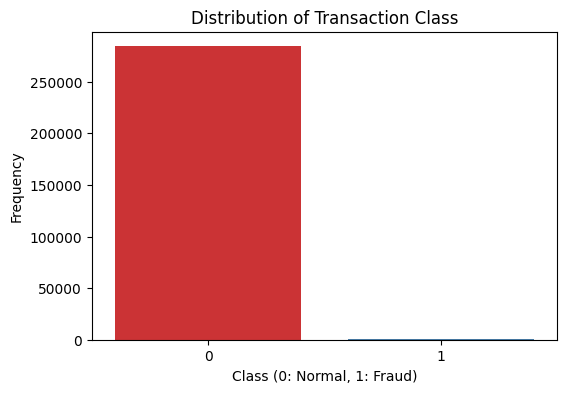

In [8]:
# Display concise summary of the dataframe (data types, non-null counts)
print("\nDataset Info:")
df.info()

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
print(df.describe())

# Check for missing values in each column
print("\nMissing Values per Column:")
print(df.isnull().sum())

# Check the distribution of the target variable 'Class'
print("\nClass Distribution (0: Normal, 1: Fraud):")
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\nPercentage of Fraudulent Transactions: {class_counts[1] / len(df) * 100:.4f}%")

# Visualize the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='Set1')
plt.title('Distribution of Transaction Class')
plt.xlabel('Class (0: Normal, 1: Fraud)')
plt.ylabel('Frequency')
plt.show()

# Data Preprocessing and Splitting

Prepare the data for modeling. This involves separating features (X) and the target variable (y), and splitting the data into training and testing sets. Scaling and handling class imbalance (e.g., undersampling) will be addressed specifically for models that require it, *after* the initial split to prevent data leakage.


In [9]:
# Separate features (X) and target (y)
# Drop 'Time' column as it might not be directly predictive or could introduce complexity
X = df.drop(['Class', 'Time'], axis=1) # Dropping 'Time' as well
y = df['Class']

# Split the data into training and testing sets
# Use stratify=y to ensure the proportion of classes is the same in train and test sets, crucial for imbalanced data
# Use random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print("\nData Splitting Shapes:")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))



Data Splitting Shapes:
X_train shape: (199364, 29)
X_test shape: (85443, 29)
y_train shape: (199364,)
y_test shape: (85443,)

Class distribution in y_train:
Class
0    0.998275
1    0.001725
Name: proportion, dtype: float64

Class distribution in y_test:
Class
0    0.998268
1    0.001732
Name: proportion, dtype: float64


# Model 1: Decision Tree

Train and evaluate a Decision Tree Classifier. Decision Trees generally don't require feature scaling.



Training Decision Tree...
Training complete.

Decision Tree Evaluation:
Confusion Matrix:
[[85261    34]
 [   38   110]]

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     85295
   Fraud (1)       0.76      0.74      0.75       148

    accuracy                           1.00     85443
   macro avg       0.88      0.87      0.88     85443
weighted avg       1.00      1.00      1.00     85443



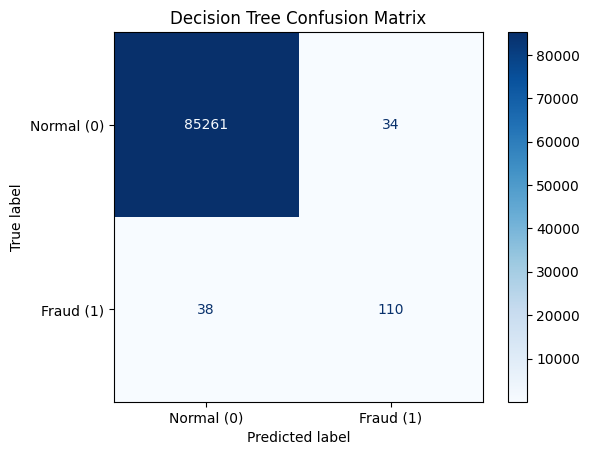

In [10]:
# Initialize the Decision Tree Classifier
# Using 'entropy' criterion as in the original notebook, and random_state for reproducibility
dtree = DecisionTreeClassifier(criterion='entropy', random_state=0)

# Train the model on the original training data
print("\nTraining Decision Tree...")
dtree.fit(X_train, y_train)
print("Training complete.")

# Make predictions on the test data
dt_predictions = dtree.predict(X_test)

# Evaluate the model
print("\nDecision Tree Evaluation:")
print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_predictions))
print("\nClassification Report:")
print(classification_report(y_test, dt_predictions, target_names=['Normal (0)', 'Fraud (1)']))

# Optional: Visualize the confusion matrix
cm_dt = confusion_matrix(y_test, dt_predictions)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Normal (0)', 'Fraud (1)'])
disp_dt.plot(cmap=plt.cm.Blues)
plt.title('Decision Tree Confusion Matrix')
plt.grid(False)
plt.show()

# Note: Plotting the full tree (tree.plot_tree) is omitted as it's often unreadable for complex trees trained on large datasets.


# Model 2: K-Nearest Neighbors (KNN)

Train and evaluate a KNN classifier. KNN is sensitive to feature scaling, so we will scale the data before training.



Scaling features for KNN...
Scaling complete.

Training KNN (K=1)...
Training complete.

KNN Evaluation (K=1):
Confusion Matrix:
[[85277    18]
 [   35   113]]

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     85295
   Fraud (1)       0.86      0.76      0.81       148

    accuracy                           1.00     85443
   macro avg       0.93      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



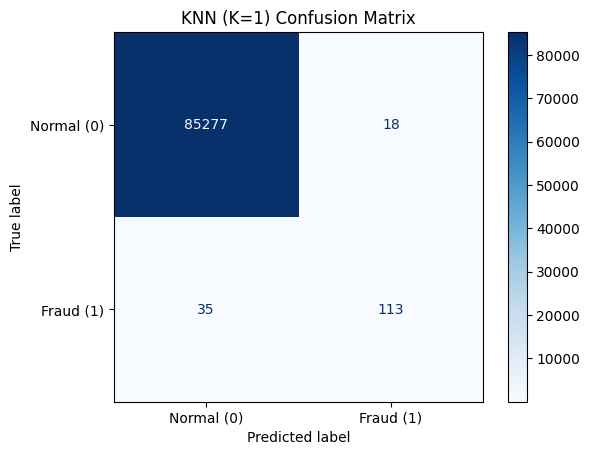


Calculating error rates for different K values (1-39)...
Completed K=5
Completed K=10
Completed K=15
Completed K=20
Completed K=25
Completed K=30
Completed K=35
Error rate calculation complete.


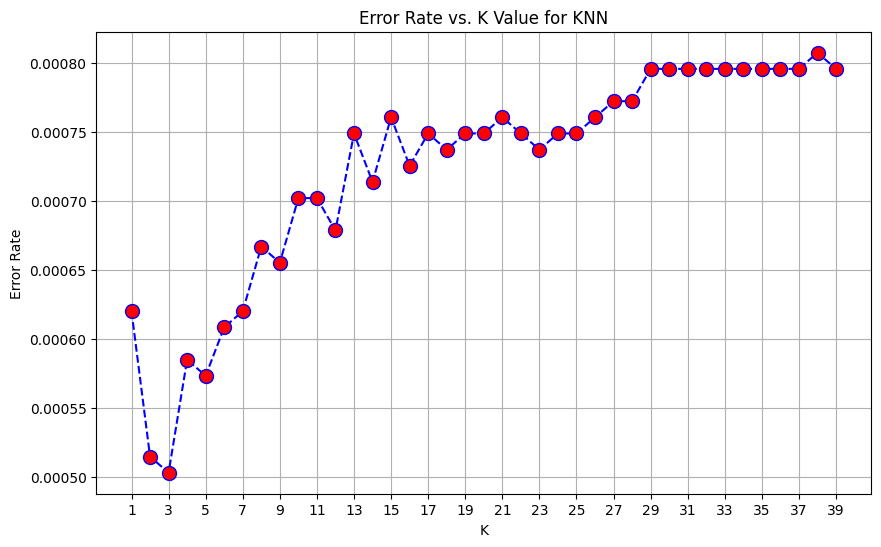


Optimal K based on minimum error rate (0.0005): 3


In [11]:
# --- KNN Preprocessing: Scaling ---
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler ONLY on the training data and transform both train and test data
print("\nScaling features for KNN...")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete.")

# --- KNN Training (K=1 initially) ---
# Initialize KNN classifier with K=1 as per the original notebook example
knn_k1 = KNeighborsClassifier(n_neighbors=1)

# Train the model on the scaled training data
print("\nTraining KNN (K=1)...")
knn_k1.fit(X_train_scaled, y_train)
print("Training complete.")

# Make predictions on the scaled test data
knn_k1_pred = knn_k1.predict(X_test_scaled)

# --- KNN Evaluation (K=1) ---
print("\nKNN Evaluation (K=1):")
print("Confusion Matrix:")
print(confusion_matrix(y_test, knn_k1_pred))
print("\nClassification Report:")
print(classification_report(y_test, knn_k1_pred, target_names=['Normal (0)', 'Fraud (1)']))

# Visualize the confusion matrix
cm_knn_k1 = confusion_matrix(y_test, knn_k1_pred)
disp_knn_k1 = ConfusionMatrixDisplay(confusion_matrix=cm_knn_k1, display_labels=['Normal (0)', 'Fraud (1)'])
disp_knn_k1.plot(cmap=plt.cm.Blues)
plt.title('KNN (K=1) Confusion Matrix')
plt.grid(False)
plt.show()


# --- KNN: Finding Optimal K (Elbow Method) ---
# Calculate error rate for K values from 1 to 39 (as in original notebook)
# Warning: This can be time-consuming
print("\nCalculating error rates for different K values (1-39)...")
error_rate = []
k_range = range(1, 40) # Check K from 1 to 39

for i in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=i)
    knn_temp.fit(X_train_scaled, y_train)
    pred_i = knn_temp.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))
    if i % 5 == 0: # Print progress
      print(f"Completed K={i}")

print("Error rate calculation complete.")

# Plot the error rate vs K value
plt.figure(figsize=(10, 6))
plt.plot(k_range, error_rate, color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value for KNN')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.xticks(list(k_range)[::2]) # Show every other K value on x-axis
plt.grid(True)
plt.show()

# Find the K with the minimum error rate
min_error = min(error_rate)
optimal_k = k_range[error_rate.index(min_error)]
print(f"\nOptimal K based on minimum error rate ({min_error:.4f}): {optimal_k}")





KNN Evaluation (K=3):
[[85286     9]
 [   34   114]]
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     85295
   Fraud (1)       0.93      0.77      0.84       148

    accuracy                           1.00     85443
   macro avg       0.96      0.89      0.92     85443
weighted avg       1.00      1.00      1.00     85443



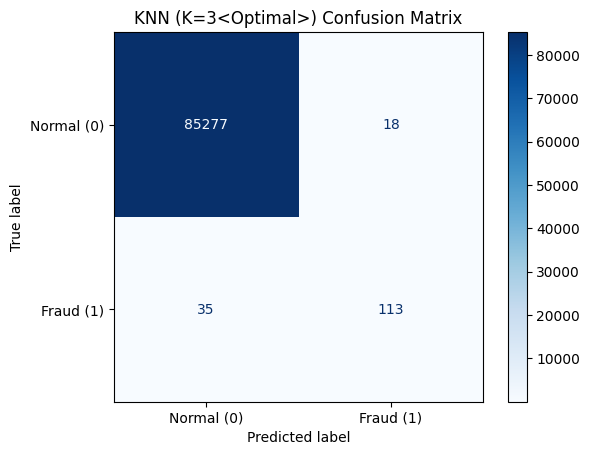

In [20]:
# Optional: Retrain and evaluate with the optimal K if different from 1
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train_scaled, y_train)
knn_optimal_pred = knn_optimal.predict(X_test_scaled)
print(f"\nKNN Evaluation (K={optimal_k}):")
print(confusion_matrix(y_test, knn_optimal_pred))
print(classification_report(y_test, knn_optimal_pred, target_names=['Normal (0)', 'Fraud (1)']))

# Visualize the confusion matrix
cm_knn_k1 = confusion_matrix(y_test, knn_k1_pred)
disp_knn_k1 = ConfusionMatrixDisplay(confusion_matrix=cm_knn_k1, display_labels=['Normal (0)', 'Fraud (1)'])
disp_knn_k1.plot(cmap=plt.cm.Blues)
plt.title('KNN (K=3<Optimal>) Confusion Matrix')
plt.grid(False)
plt.show()


# Model 3: Logistic Regression

Train and evaluate a Logistic Regression model. The original notebook applied undersampling to handle class imbalance for this model. We will apply `RandomUnderSampler` to the *training data* only. Logistic Regression can also benefit from scaling, so we'll use the scaled data from the KNN section.



Training Logistic Regression...
Training complete.

Logistic Regression Evaluation:
Confusion Matrix:
[[85280    15]
 [   57    91]]

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     85295
   Fraud (1)       0.86      0.61      0.72       148

    accuracy                           1.00     85443
   macro avg       0.93      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443

AUC Score: 0.9579


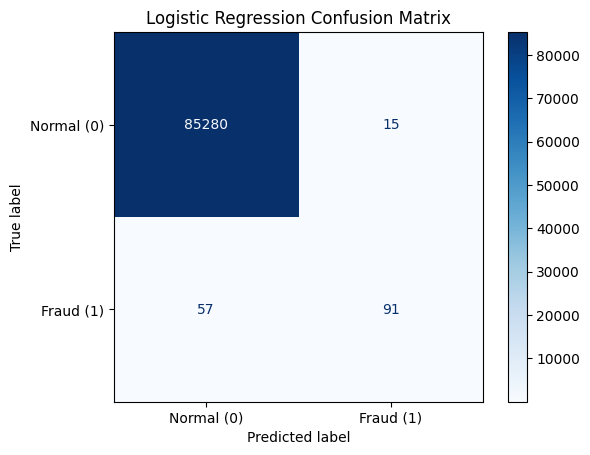


Accuracy on Training data: 0.9992
Accuracy on Test data: 0.9992


In [13]:
X_train_final_lr = X_train_scaled
y_train_final_lr = y_train

# --- Logistic Regression Training ---
# Initialize Logistic Regression model
# Increase max_iter if convergence warnings appear, add random_state
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
print("\nTraining Logistic Regression...")
log_model.fit(X_train_final_lr, y_train_final_lr)
print("Training complete.")

# --- Logistic Regression Evaluation ---
# Predict on the original (scaled) test data
log_pred = log_model.predict(X_test_scaled)
log_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1] # Probabilities for AUC

# Evaluate the model
# Note: Evaluation is always done on the original, representative test set (y_test)
print("\nLogistic Regression Evaluation:")
print("Confusion Matrix:")
print(confusion_matrix(y_test, log_pred))
print("\nClassification Report:")
print(classification_report(y_test, log_pred, target_names=['Normal (0)', 'Fraud (1)']))
print(f"AUC Score: {roc_auc_score(y_test, log_pred_proba):.4f}")

# Visualize the confusion matrix
cm_lr = confusion_matrix(y_test, log_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Normal (0)', 'Fraud (1)'])
disp_lr.plot(cmap=plt.cm.Blues)
plt.title('Logistic Regression Confusion Matrix')
plt.grid(False)
plt.show()

# Evaluate accuracy on training and test data (as in original notebook)
# Predict on training data (the one used for fitting)
X_train_pred_lr = log_model.predict(X_train_final_lr)
training_data_accuracy = accuracy_score(X_train_pred_lr, y_train_final_lr)
print(f'\nAccuracy on Training data: {training_data_accuracy:.4f}')

# Test data accuracy
test_data_accuracy = accuracy_score(log_pred, y_test)
print(f'Accuracy on Test data: {test_data_accuracy:.4f}')



Logistic Regression Preprocessing: Undersampling


Applying Random Undersampling to the training data...
Undersampling complete.
Original training shape: 199364
Resampled training shape: 688
Class distribution in resampled training data:
Class
0    0.5
1    0.5
Name: proportion, dtype: float64

Training Logistic Regression...
Training complete.

Logistic Regression Evaluation:
Confusion Matrix:
[[83218  2077]
 [   17   131]]

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      0.98      0.99     85295
   Fraud (1)       0.06      0.89      0.11       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.55     85443
weighted avg       1.00      0.98      0.99     85443

AUC Score: 0.9726


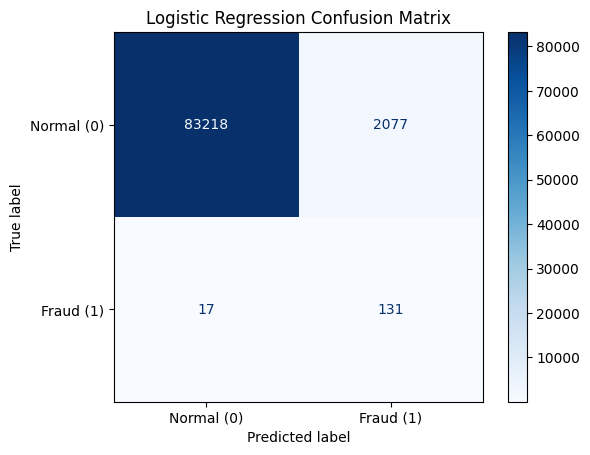


Accuracy on Training data: 0.9593
Accuracy on Test data: 0.9755


In [14]:

from imblearn.under_sampling import RandomUnderSampler
print("\nApplying Random Undersampling to the training data...")
rus = RandomUnderSampler(random_state=42)
X_train_scaled_res, y_train_res = rus.fit_resample(X_train_scaled, y_train)
print("Undersampling complete.")
print("Original training shape:", y_train.shape[0])
print("Resampled training shape:", y_train_res.shape[0])
print("Class distribution in resampled training data:")
print(pd.Series(y_train_res).value_counts(normalize=True))
X_train_final_lr = X_train_scaled_res
y_train_final_lr = y_train_res


# --- Logistic Regression Training ---
# Initialize Logistic Regression model
# Increase max_iter if convergence warnings appear, add random_state
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
# If undersampling was done, train on X_train_scaled_res, y_train_res
# Otherwise, train on X_train_scaled, y_train
print("\nTraining Logistic Regression...")
log_model.fit(X_train_scaled_res, y_train_res)
print("Training complete.")

# --- Logistic Regression Evaluation ---
# Predict on the original (scaled) test data
log_pred = log_model.predict(X_test_scaled)
log_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1] # Probabilities for AUC

# Evaluate the model
# Note: Evaluation is always done on the original, representative test set (y_test)
print("\nLogistic Regression Evaluation:")
print("Confusion Matrix:")
print(confusion_matrix(y_test, log_pred))
print("\nClassification Report:")
print(classification_report(y_test, log_pred, target_names=['Normal (0)', 'Fraud (1)']))
print(f"AUC Score: {roc_auc_score(y_test, log_pred_proba):.4f}")

# Visualize the confusion matrix
cm_lr = confusion_matrix(y_test, log_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Normal (0)', 'Fraud (1)'])
disp_lr.plot(cmap=plt.cm.Blues)
plt.title('Logistic Regression Confusion Matrix')
plt.grid(False)
plt.show()

# Evaluate accuracy on training and test data (as in original notebook)
# Predict on training data (the one used for fitting)
X_train_pred_lr = log_model.predict(X_train_final_lr)
training_data_accuracy = accuracy_score(X_train_pred_lr, y_train_final_lr)
print(f'\nAccuracy on Training data: {training_data_accuracy:.4f}')

# Test data accuracy
test_data_accuracy = accuracy_score(log_pred, y_test)
print(f'Accuracy on Test data: {test_data_accuracy:.4f}')



# Model 4: Support Vector Machine (SVM)

Train and evaluate a Support Vector Machine classifier. SVMs are sensitive to feature scaling. The original notebook also applied undersampling for SVM. We will use the scaled data and apply undersampling to the training set.



Training SVM...
Training complete.

SVM Evaluation:
Accuracy: 0.9993
Precision: 0.9674
Recall: 0.6014
F1 Score: 0.7417
AUC Score: 0.9303

Confusion Matrix:
[[85292     3]
 [   59    89]]

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     85295
   Fraud (1)       0.97      0.60      0.74       148

    accuracy                           1.00     85443
   macro avg       0.98      0.80      0.87     85443
weighted avg       1.00      1.00      1.00     85443



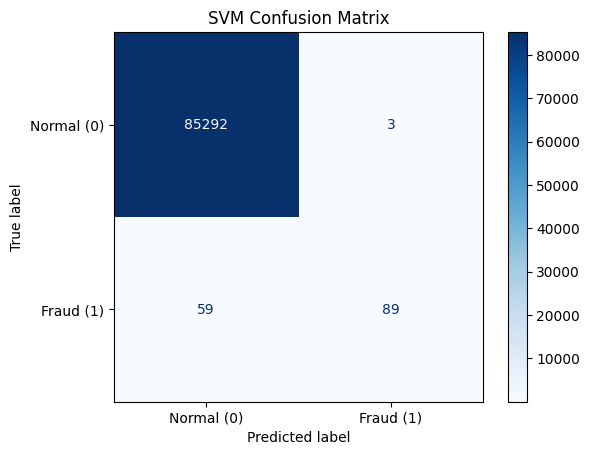

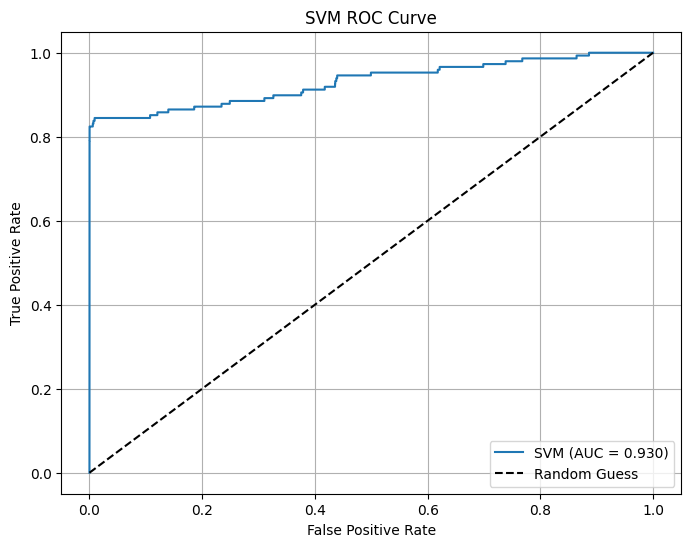

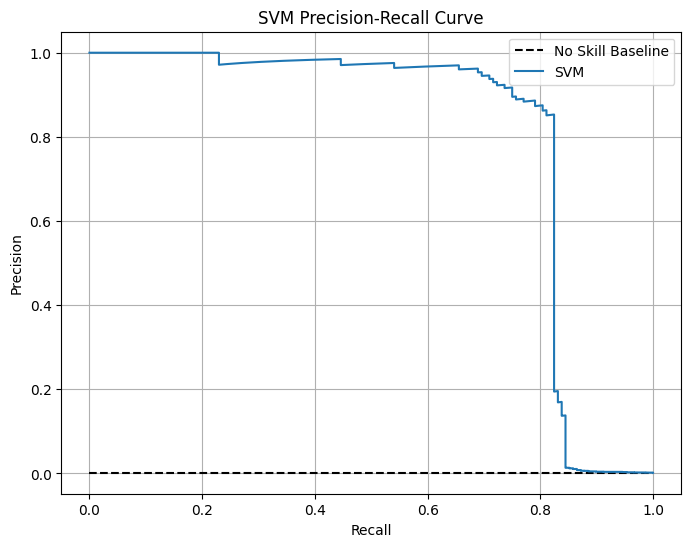

In [15]:
X_train_final_svm = X_train_scaled
y_train_final_svm = y_train

# --- SVM Training ---
# Initialize SVM classifier
# Use probability=True to get probabilities for ROC/AUC, add random_state
# Note: SVM training can be computationally expensive, especially on large datasets.
svm_model = SVC(probability=True, random_state=42)

# Train the model
# If undersampling was done, train on X_train_svm_res, y_train_svm_res
# Otherwise, train on X_train_scaled, y_train
print("\nTraining SVM...")
svm_model.fit(X_train_final_svm, y_train_final_svm)
print("Training complete.")

# --- SVM Evaluation ---
# Predict on the original (scaled) test data
svm_pred = svm_model.predict(X_test_scaled)
svm_pred_proba = svm_model.predict_proba(X_test_scaled)[:, 1] # Probabilities for AUC/ROC

# Evaluate the model
# Note: Evaluation is always done on the original, representative test set (y_test)
print("\nSVM Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, svm_pred):.4f}")
print(f"Precision: {precision_score(y_test, svm_pred):.4f}")
print(f"Recall: {recall_score(y_test, svm_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, svm_pred):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, svm_pred_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))
print("\nClassification Report:")
print(classification_report(y_test, svm_pred, target_names=['Normal (0)', 'Fraud (1)']))

# Plot Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_pred)
# cm_svm_df = pd.DataFrame(matrix_svm, index=['not_fraud', 'fraud'], columns=['not_fraud', 'fraud']) # Alternative display
# sns.heatmap(cm_svm_df, annot=True, cbar=None, cmap="Blues", fmt = 'g')
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Normal (0)', 'Fraud (1)'])
disp_svm.plot(cmap=plt.cm.Blues)
plt.title("SVM Confusion Matrix")#, plt.tight_layout()
# plt.ylabel("True Class"), plt.xlabel("Predicted Class") # Provided by ConfusionMatrixDisplay
plt.grid(False)
plt.show()

# Plot ROC Curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_pred_proba)
auc_svm = roc_auc_score(y_test, svm_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess') # Reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend(loc=4)
plt.grid(True)
plt.show()

# Plot Precision-Recall Curve
svm_precision, svm_recall, _ = precision_recall_curve(y_test, svm_pred_proba)
# Calculate the no-skill line (proportion of positive class)
no_skill = len(y_test[y_test==1]) / len(y_test)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', color='black', label='No Skill Baseline')
plt.plot(svm_recall, svm_precision, label='SVM')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('SVM Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()



SVM Preprocessing: Undersampling



Applying Random Undersampling to the scaled training data for SVM...
Undersampling complete.
Resampled SVM training shape: 688
Class distribution in resampled SVM training data:
Class
0    0.5
1    0.5
Name: proportion, dtype: float64

Training SVM...
Training complete.

SVM Evaluation:
Accuracy: 0.9875
Precision: 0.1058
Recall: 0.8378
F1 Score: 0.1879
AUC Score: 0.9727

Confusion Matrix:
[[84247  1048]
 [   24   124]]

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      0.99     85295
   Fraud (1)       0.11      0.84      0.19       148

    accuracy                           0.99     85443
   macro avg       0.55      0.91      0.59     85443
weighted avg       1.00      0.99      0.99     85443



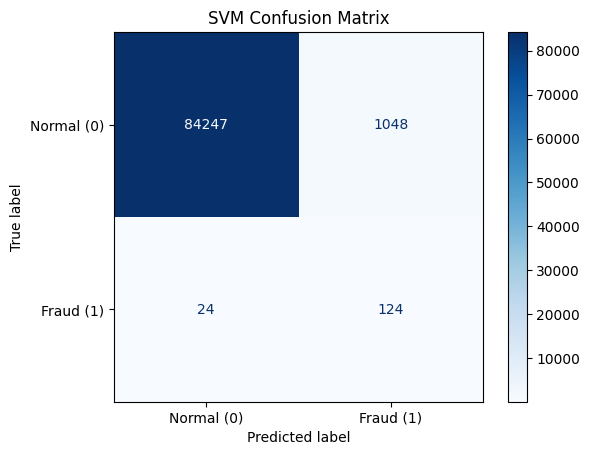

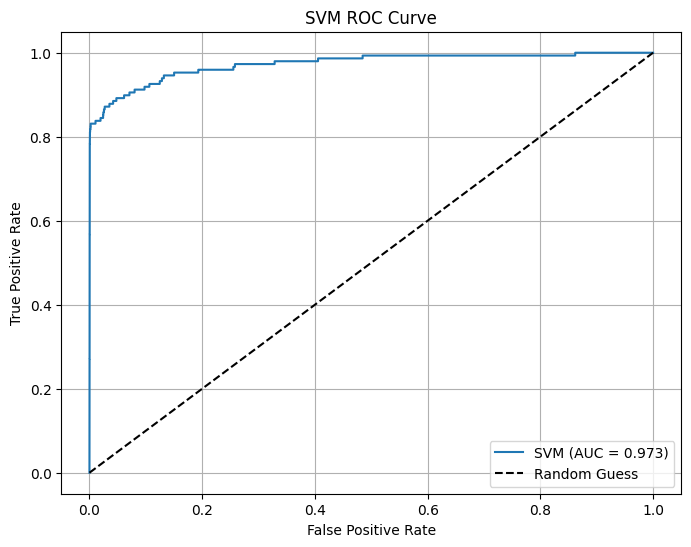

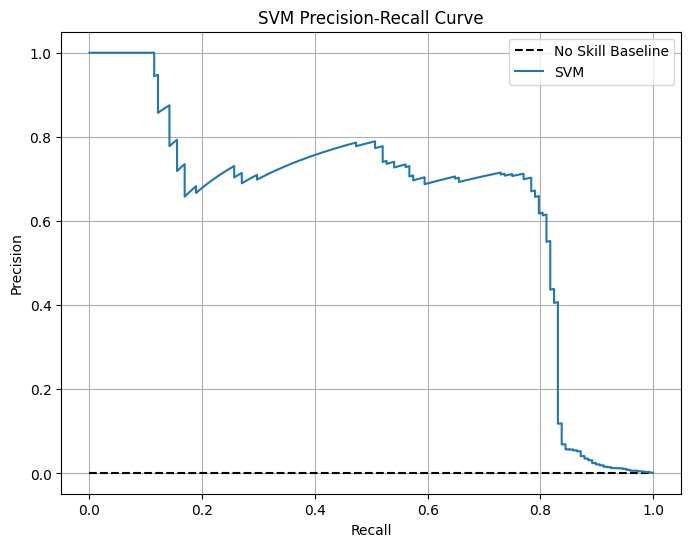

In [16]:

# Requires 'imblearn' library: pip install imbalanced-learn

from imblearn.under_sampling import RandomUnderSampler
print("\nApplying Random Undersampling to the scaled training data for SVM...")
rus_svm = RandomUnderSampler(random_state=42) # Can reuse rus object or create new
X_train_svm_res, y_train_svm_res = rus_svm.fit_resample(X_train_scaled, y_train)
print("Undersampling complete.")
print("Resampled SVM training shape:", y_train_svm_res.shape[0])
print("Class distribution in resampled SVM training data:")
print(pd.Series(y_train_svm_res).value_counts(normalize=True))
X_train_final_svm = X_train_svm_res
y_train_final_svm = y_train_svm_res


# --- SVM Training ---
# Initialize SVM classifier
# Use probability=True to get probabilities for ROC/AUC, add random_state
# Note: SVM training can be computationally expensive, especially on large datasets.
svm_model = SVC(probability=True, random_state=42)

# Train the model
# If undersampling was done, train on X_train_svm_res, y_train_svm_res
# Otherwise, train on X_train_scaled, y_train
print("\nTraining SVM...")
svm_model.fit(X_train_svm_res, y_train_svm_res)
print("Training complete.")

# --- SVM Evaluation ---
# Predict on the original (scaled) test data
svm_pred = svm_model.predict(X_test_scaled)
svm_pred_proba = svm_model.predict_proba(X_test_scaled)[:, 1] # Probabilities for AUC/ROC

# Evaluate the model
# Note: Evaluation is always done on the original, representative test set (y_test)
print("\nSVM Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, svm_pred):.4f}")
print(f"Precision: {precision_score(y_test, svm_pred):.4f}")
print(f"Recall: {recall_score(y_test, svm_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, svm_pred):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, svm_pred_proba):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))
print("\nClassification Report:")
print(classification_report(y_test, svm_pred, target_names=['Normal (0)', 'Fraud (1)']))

# Plot Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_pred)
# cm_svm_df = pd.DataFrame(matrix_svm, index=['not_fraud', 'fraud'], columns=['not_fraud', 'fraud']) # Alternative display
# sns.heatmap(cm_svm_df, annot=True, cbar=None, cmap="Blues", fmt = 'g')
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['Normal (0)', 'Fraud (1)'])
disp_svm.plot(cmap=plt.cm.Blues)
plt.title("SVM Confusion Matrix")#, plt.tight_layout()
# plt.ylabel("True Class"), plt.xlabel("Predicted Class") # Provided by ConfusionMatrixDisplay
plt.grid(False)
plt.show()

# Plot ROC Curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_pred_proba)
auc_svm = roc_auc_score(y_test, svm_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess') # Reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM ROC Curve')
plt.legend(loc=4)
plt.grid(True)
plt.show()

# Plot Precision-Recall Curve
svm_precision, svm_recall, _ = precision_recall_curve(y_test, svm_pred_proba)
# Calculate the no-skill line (proportion of positive class)
no_skill = len(y_test[y_test==1]) / len(y_test)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', color='black', label='No Skill Baseline')
plt.plot(svm_recall, svm_precision, label='SVM')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('SVM Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()



# End of Notebook

This concludes the refactored analysis, covering data loading, EDA, preprocessing, and training/evaluation for Decision Tree, KNN, Logistic Regression, and SVM models on the credit card fraud dataset.


In [22]:
# --- Recalculate Probabilities if Needed ---
# Decision Tree needs probabilities for AUC
dt_pred_proba = dtree.predict_proba(X_test)[:, 1]

# KNN (K=1) needs probabilities for AUC
# Remember to use the SCALED test data for KNN
knn_k1_pred_proba = knn_k1.predict_proba(X_test_scaled)[:, 1]
knn_optimal_pred_proba = knn_k1.predict_proba(X_test_scaled)[:, 1]

# Logistic Regression probabilities (already calculated as log_pred_proba)
# SVM probabilities (already calculated as svm_pred_proba)


# --- Gather Metrics ---
models_performance = {}

# Decision Tree Metrics
models_performance['Decision Tree'] = {
    'Accuracy': accuracy_score(y_test, dt_predictions),
    'Precision (Fraud)': precision_score(y_test, dt_predictions, pos_label=1),
    'Recall (Fraud)': recall_score(y_test, dt_predictions, pos_label=1),
    'F1-Score (Fraud)': f1_score(y_test, dt_predictions, pos_label=1),
    'AUC': roc_auc_score(y_test, dt_pred_proba)
}

# KNN (K=1) Metrics
models_performance['KNN (K=1)'] = {
    'Accuracy': accuracy_score(y_test, knn_k1_pred),
    'Precision (Fraud)': precision_score(y_test, knn_k1_pred, pos_label=1),
    'Recall (Fraud)': recall_score(y_test, knn_k1_pred, pos_label=1),
    'F1-Score (Fraud)': f1_score(y_test, knn_k1_pred, pos_label=1),
    'AUC': roc_auc_score(y_test, knn_k1_pred_proba)
}



# KNN (K=3 optimal) Metrics
models_performance['KNN (K=3[optimal])'] = {
    'Accuracy': accuracy_score(y_test, knn_optimal_pred),
    'Precision (Fraud)': precision_score(y_test, knn_optimal_pred, pos_label=1),
    'Recall (Fraud)': recall_score(y_test, knn_optimal_pred, pos_label=1),
    'F1-Score (Fraud)': f1_score(y_test, knn_optimal_pred, pos_label=1),
    'AUC': roc_auc_score(y_test, knn_optimal_pred_proba)
}

# Logistic Regression Metrics
# (Using log_pred and log_pred_proba calculated previously)
models_performance['Logistic Regression'] = {
    'Accuracy': accuracy_score(y_test, log_pred),
    'Precision (Fraud)': precision_score(y_test, log_pred, pos_label=1),
    'Recall (Fraud)': recall_score(y_test, log_pred, pos_label=1),
    'F1-Score (Fraud)': f1_score(y_test, log_pred, pos_label=1),
    'AUC': roc_auc_score(y_test, log_pred_proba) # Already calculated
}

# SVM Metrics
# (Using svm_pred and svm_pred_proba calculated previously)
models_performance['SVM'] = {
    'Accuracy': accuracy_score(y_test, svm_pred),
    'Precision (Fraud)': precision_score(y_test, svm_pred, pos_label=1),
    'Recall (Fraud)': recall_score(y_test, svm_pred, pos_label=1),
    'F1-Score (Fraud)': f1_score(y_test, svm_pred, pos_label=1),
    'AUC': roc_auc_score(y_test, svm_pred_proba) # Already calculated
}

# --- Display Comparison Table ---
comparison_df = pd.DataFrame(models_performance).T # Transpose for models as rows
comparison_df = comparison_df.round(4) # Format to 4 decimal places

print("\nModel Performance Comparison on Test Set:")
print(comparison_df)

# --- Determine "Best" Model based on a chosen metric (e.g., F1-Score for Fraud) ---
best_f1_model = comparison_df['F1-Score (Fraud)'].idxmax()
best_recall_model = comparison_df['Recall (Fraud)'].idxmax()
best_precision_model = comparison_df['Precision (Fraud)'].idxmax()
best_auc_model = comparison_df['AUC'].idxmax()

print(f"\n--- Best Model Analysis ---")
print(f"Highest F1-Score (Fraud): {best_f1_model} ({comparison_df.loc[best_f1_model, 'F1-Score (Fraud)']})")
print(f"Highest Recall (Fraud): {best_recall_model} ({comparison_df.loc[best_recall_model, 'Recall (Fraud)']})")
print(f"Highest Precision (Fraud): {best_precision_model} ({comparison_df.loc[best_precision_model, 'Precision (Fraud)']})")
print(f"Highest AUC: {best_auc_model} ({comparison_df.loc[best_auc_model, 'AUC']})")




Model Performance Comparison on Test Set:
                     Accuracy  Precision (Fraud)  Recall (Fraud)  \
Decision Tree          0.9992             0.7639          0.7432   
KNN (K=1)              0.9994             0.8626          0.7635   
KNN (K=3[optimal])     0.9995             0.9268          0.7703   
Logistic Regression    0.9755             0.0593          0.8851   
SVM                    0.9875             0.1058          0.8378   

                     F1-Score (Fraud)     AUC  
Decision Tree                  0.7534  0.8714  
KNN (K=1)                      0.8100  0.8817  
KNN (K=3[optimal])             0.8413  0.8817  
Logistic Regression            0.1112  0.9726  
SVM                            0.1879  0.9727  

--- Best Model Analysis ---
Highest F1-Score (Fraud): KNN (K=3[optimal]) (0.8413)
Highest Recall (Fraud): Logistic Regression (0.8851)
Highest Precision (Fraud): KNN (K=3[optimal]) (0.9268)
Highest AUC: SVM (0.9727)
